In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from scipy import signal, stats, optimize
from scipy.stats import spearmanr
from scipy.stats import permutation_test
from statsmodels.stats.multitest import multipletests
import logging
from typing import Dict, List, Tuple, Optional
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import json
import warnings
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
features = pd.read_csv("resting_state_features.csv")
features.head()

,subject_id,rpl_alpha,tar,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,resting_upper_beta_power,smr_strength,IAF_c3,alpha_peak_amp_c3,beta_peak_amp_c3,beta_center_freq_c3,aperiodic_exp_c3,IAF_c4,alpha_peak_amp_c4,beta_peak_amp_c4,beta_center_freq_c4,aperiodic_exp_c4,alpha_var_C3,alpha_cv_C3,alpha_var_C4,alpha_cv_C4,coherence_mu,coherence_beta,coherence_low_beta,coherence_upper_beta,pse_C3,pse_C4,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg
0,S001,0.194741,0.675380,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,3.650203e-12,7.383304,11.980874,9.004301,4.833007,23.823147,0.449432,11.937756,5.766411,3.145414,23.173486,0.180806,6.602452e-12,0.061025,4.665315e-12,0.043505,0.141254,0.115479,0.123208,0.109520,0.977108,0.988366,0.994231,0.986568,0.002716,0.009505,0.013579,0.008600
1,S002,0.202166,0.624098,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,8.136274e-12,5.825720,11.736620,3.738507,4.490563,23.014317,0.334747,9.268365,4.480069,7.161100,23.689520,0.345764,2.553285e-12,0.024649,1.427419e-12,0.013958,0.175790,0.141092,0.135503,0.144505,0.997750,0.998843,0.987786,0.994793,0.005431,0.080113,0.021726,0.035757
2,S003,0.099183,1.945952,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,1.332839e-10,1.905904,NaN,1.666650,0.692466,19.755725,0.243205,NaN,2.145215,1.116253,20.606421,0.195352,5.254494e-12,0.045895,2.672222e-10,0.415792,0.123528,0.122243,0.121730,0.122025,0.980752,0.952377,0.995232,0.976120,0.002716,0.021726,0.002716,0.009052
3,S004,0.094906,1.370996,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,1.457215e-12,2.282486,NaN,1.366666,1.610355,23.556273,0.281871,NaN,1.339218,1.519870,20.768829,0.225990,8.387822e-13,0.008189,7.112925e-13,0.006989,0.124825,0.133027,0.110143,0.149123,0.998296,0.999229,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074
4,S005,0.058463,3.374198,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,3.188668e-12,1.580299,NaN,1.740182,1.426972,16.904285,0.214548,8.512015,1.213306,1.068930,19.043910,0.195724,1.508903e-12,0.014573,3.418360e-12,0.031818,0.167935,0.127048,0.148673,0.111402,0.996957,0.991942,0.998916,0.995939,0.105913,0.002716,0.109986,0.072872


In [4]:
features.shape

(109, 39)

In [5]:
# get labels in df form

In [6]:
with open('json-from-bci-classifier/ground_truth_labels.json') as f:
    data = json.load(f)

rows = []
for task_name, task_data in data['tasks'].items():
    for subject in task_data['subjects']:
        rows.append({
            'subject_id': f"S{subject['subject_id']:03d}",
            'task': task_name,
            'accuracy': subject['accuracy'],
            'accuracy_std': subject['accuracy_std'],
            'n_trials': subject['n_trials'],
            'success': subject['success'] 
        })

labels = pd.DataFrame(rows)
labels.head(10)

,subject_id,task,accuracy,accuracy_std,n_trials,success
0,S001,left_right,0.666667,0.210819,45,True
1,S002,left_right,0.933333,0.054433,45,True
2,S003,left_right,0.688889,0.108866,45,True
3,S004,left_right,0.577778,0.147406,45,True
4,S005,left_right,0.533333,0.163299,45,True
5,S006,left_right,0.444444,0.099381,45,True
6,S007,left_right,0.977778,0.044444,45,True
7,S008,left_right,0.555556,0.157135,45,True
8,S009,left_right,0.400000,0.088889,45,True
9,S010,left_right,0.444444,0.140546,45,True


In [7]:
# get labels to 109 rows
labels = labels.pivot(index = 'subject_id', columns = 'task', values = 'accuracy').reset_index()
labels.columns = ['subject_id','accuracy_hands_feet', 'accuracy_left_right']

In [8]:
labels.head(10)

,subject_id,accuracy_hands_feet,accuracy_left_right
0,S001,0.888889,0.666667
1,S002,0.800000,0.933333
2,S003,0.533333,0.688889
3,S004,0.666667,0.577778
4,S005,0.466667,0.533333
5,S006,0.511111,0.444444
6,S007,0.933333,0.977778
7,S008,0.911111,0.555556
8,S009,0.466667,0.400000
9,S010,0.844444,0.444444


In [9]:
# will focus on predicting left/right for now
labels['accuracy_avg'] = (labels['accuracy_hands_feet'] + labels['accuracy_left_right']) / 2.0
labels

,subject_id,accuracy_hands_feet,accuracy_left_right,accuracy_avg
0,S001,0.888889,0.666667,0.777778
1,S002,0.800000,0.933333,0.866667
2,S003,0.533333,0.688889,0.611111
3,S004,0.666667,0.577778,0.622222
4,S005,0.466667,0.533333,0.500000
...,...,...,...,...
104,S105,0.755556,0.600000,0.677778
105,S106,0.888889,0.555556,0.722222
106,S107,0.666667,0.511111,0.588889
107,S108,0.688889,0.755556,0.722222


In [10]:
labels.shape

(109, 4)

In [11]:
df = features.merge(labels, on = 'subject_id', how = 'inner')
df.head(5)

,subject_id,rpl_alpha,tar,resting_alpha_power,resting_total_power,alpha_power_c3,alpha_power_c4,alpha_asymmetry,rpl_lower_beta,resting_lower_beta_power,rpl_upper_beta,resting_upper_beta_power,smr_strength,IAF_c3,alpha_peak_amp_c3,beta_peak_amp_c3,beta_center_freq_c3,aperiodic_exp_c3,IAF_c4,alpha_peak_amp_c4,beta_peak_amp_c4,beta_center_freq_c4,aperiodic_exp_c4,alpha_var_C3,alpha_cv_C3,alpha_var_C4,alpha_cv_C4,coherence_mu,coherence_beta,coherence_low_beta,coherence_upper_beta,pse_C3,pse_C4,pse_Cz,pse_avg,lzc_C3,lzc_C4,lzc_Cz,lzc_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg
0,S001,0.194741,0.675380,8.242792e-12,4.232705e-11,6.628976e-12,1.039650e-11,0.450019,0.079778,3.376770e-12,0.086238,3.650203e-12,7.383304,11.980874,9.004301,4.833007,23.823147,0.449432,11.937756,5.766411,3.145414,23.173486,0.180806,6.602452e-12,0.061025,4.665315e-12,0.043505,0.141254,0.115479,0.123208,0.109520,0.977108,0.988366,0.994231,0.986568,0.002716,0.009505,0.013579,0.008600,0.888889,0.666667,0.777778
1,S002,0.202166,0.624098,7.847295e-12,3.881609e-11,6.816839e-12,4.408732e-12,-0.435809,0.112889,4.381919e-12,0.209611,8.136274e-12,5.825720,11.736620,3.738507,4.490563,23.014317,0.334747,9.268365,4.480069,7.161100,23.689520,0.345764,2.553285e-12,0.024649,1.427419e-12,0.013958,0.175790,0.141092,0.135503,0.144505,0.997750,0.998843,0.987786,0.994793,0.005431,0.080113,0.021726,0.035757,0.800000,0.933333,0.866667
2,S003,0.099183,1.945952,3.021946e-10,3.046833e-09,1.990851e-11,8.757055e-10,3.783883,0.061178,1.863987e-10,0.043745,1.332839e-10,1.905904,NaN,1.666650,0.692466,19.755725,0.243205,NaN,2.145215,1.116253,20.606421,0.195352,5.254494e-12,0.045895,2.672222e-10,0.415792,0.123528,0.122243,0.121730,0.122025,0.980752,0.952377,0.995232,0.976120,0.002716,0.021726,0.002716,0.009052,0.533333,0.688889,0.611111
3,S004,0.094906,1.370996,2.162228e-12,2.278282e-11,2.793310e-12,2.282966e-12,-0.201752,0.075321,1.716026e-12,0.063961,1.457215e-12,2.282486,NaN,1.366666,1.610355,23.556273,0.281871,NaN,1.339218,1.519870,20.768829,0.225990,8.387822e-13,0.008189,7.112925e-13,0.006989,0.124825,0.133027,0.110143,0.149123,0.998296,0.999229,0.999874,0.999133,0.002716,0.002716,0.006789,0.004074,0.666667,0.577778,0.622222
4,S005,0.058463,3.374198,4.349915e-12,7.440495e-11,4.316240e-12,5.436551e-12,0.230760,0.059404,4.419965e-12,0.042856,3.188668e-12,1.580299,NaN,1.740182,1.426972,16.904285,0.214548,8.512015,1.213306,1.068930,19.043910,0.195724,1.508903e-12,0.014573,3.418360e-12,0.031818,0.167935,0.127048,0.148673,0.111402,0.996957,0.991942,0.998916,0.995939,0.105913,0.002716,0.109986,0.072872,0.466667,0.533333,0.500000


# Columns

In [12]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
tar
resting_alpha_power
resting_total_power
alpha_power_c3
alpha_power_c4
alpha_asymmetry
rpl_lower_beta
resting_lower_beta_power
rpl_upper_beta
resting_upper_beta_power
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_beta
coherence_low_beta
coherence_upper_beta
pse_C3
pse_C4
pse_Cz
pse_avg
lzc_C3
lzc_C4
lzc_Cz
lzc_avg
accuracy_hands_feet
accuracy_left_right
accuracy_avg


# Missing Values

In [13]:
missing_val_cols = []
for col in df.columns:
    if df[col].isna().sum() > 0:
        missing_val_cols.append(col)
        print(missing_val_cols[-1], ": ", df[col].isna().sum())


IAF_c3 :  57
IAF_c4 :  41


In [14]:
missing_df = df[['IAF_c3', 'IAF_c4']]
missing_df

,IAF_c3,IAF_c4
0,11.980874,11.937756
1,11.736620,9.268365
2,NaN,NaN
3,NaN,NaN
4,NaN,8.512015
...,...,...
104,10.613576,NaN
105,NaN,9.759662
106,11.598350,9.912356
107,10.853828,10.847838


In [15]:
# check how many rows have at least one missing value
missing_df[(missing_df['IAF_c3'].isna()) | (missing_df['IAF_c4'].isna())]

,IAF_c3,IAF_c4
2,NaN,NaN
3,NaN,NaN
4,NaN,8.512015
5,NaN,NaN
7,8.283555,NaN
...,...,...
100,NaN,NaN
103,NaN,9.598530
104,10.613576,NaN
105,NaN,9.759662


### Notes:
 - subjects with missing values in C3 or C4 are not the same . Many different subjects have one or both missing values from either electrode
 - missingness in those columns is caused by edge values for IAF, which are unreliable and best kept missing
 - Resting Alpha Power and IAF are related. For missing values, Resting alpha power can instead be used
 - About half of the rows have at least one missing value (over half, 62/109 = 57%)
 - Missingness Mechanism: Not Missing at Random (NMAR), because whether or not a value is missing depends on what that value would have been

# Initial dropping of redundant columns

In [16]:
to_drop = [
    'resting_alpha_power', # captured by rpl_alpha
    'resting_total_power', # captured by rpl_alpha
    'alpha_power_c3', # captured by rpl_alpha
    'alpha_power_c4',
    'resting_lower_beta_power', # captured by rpl_lower_beta
    'resting_upper_beta_power', # captured by rpl_upper_beta
    'coherence_beta', # captured by coherence_lower/upper_beta
    'pse_C3', # captured by pse_avg
    'pse_C4',
    'pse_Cz',
    'lzc_C3', # captured by lzc_avg
    'lzc_C4',
    'lzc_Cz'
]

In [17]:
df = df.drop(columns = to_drop)

In [18]:
df.head(5)

,subject_id,rpl_alpha,tar,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,alpha_peak_amp_c3,beta_peak_amp_c3,beta_center_freq_c3,aperiodic_exp_c3,IAF_c4,alpha_peak_amp_c4,beta_peak_amp_c4,beta_center_freq_c4,aperiodic_exp_c4,alpha_var_C3,alpha_cv_C3,alpha_var_C4,alpha_cv_C4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg
0,S001,0.194741,0.675380,0.450019,0.079778,0.086238,7.383304,11.980874,9.004301,4.833007,23.823147,0.449432,11.937756,5.766411,3.145414,23.173486,0.180806,6.602452e-12,0.061025,4.665315e-12,0.043505,0.141254,0.123208,0.109520,0.986568,0.008600,0.888889,0.666667,0.777778
1,S002,0.202166,0.624098,-0.435809,0.112889,0.209611,5.825720,11.736620,3.738507,4.490563,23.014317,0.334747,9.268365,4.480069,7.161100,23.689520,0.345764,2.553285e-12,0.024649,1.427419e-12,0.013958,0.175790,0.135503,0.144505,0.994793,0.035757,0.800000,0.933333,0.866667
2,S003,0.099183,1.945952,3.783883,0.061178,0.043745,1.905904,NaN,1.666650,0.692466,19.755725,0.243205,NaN,2.145215,1.116253,20.606421,0.195352,5.254494e-12,0.045895,2.672222e-10,0.415792,0.123528,0.121730,0.122025,0.976120,0.009052,0.533333,0.688889,0.611111
3,S004,0.094906,1.370996,-0.201752,0.075321,0.063961,2.282486,NaN,1.366666,1.610355,23.556273,0.281871,NaN,1.339218,1.519870,20.768829,0.225990,8.387822e-13,0.008189,7.112925e-13,0.006989,0.124825,0.110143,0.149123,0.999133,0.004074,0.666667,0.577778,0.622222
4,S005,0.058463,3.374198,0.230760,0.059404,0.042856,1.580299,NaN,1.740182,1.426972,16.904285,0.214548,8.512015,1.213306,1.068930,19.043910,0.195724,1.508903e-12,0.014573,3.418360e-12,0.031818,0.167935,0.148673,0.111402,0.995939,0.072872,0.466667,0.533333,0.500000


# Averaging C3/C4 columns

In [19]:
for i in df.columns:
    print(i)

subject_id
rpl_alpha
tar
alpha_asymmetry
rpl_lower_beta
rpl_upper_beta
smr_strength
IAF_c3
alpha_peak_amp_c3
beta_peak_amp_c3
beta_center_freq_c3
aperiodic_exp_c3
IAF_c4
alpha_peak_amp_c4
beta_peak_amp_c4
beta_center_freq_c4
aperiodic_exp_c4
alpha_var_C3
alpha_cv_C3
alpha_var_C4
alpha_cv_C4
coherence_mu
coherence_low_beta
coherence_upper_beta
pse_avg
lzc_avg
accuracy_hands_feet
accuracy_left_right
accuracy_avg


In [20]:
# IAF avg - will actually keep both for now because of missing values

In [21]:
# Alpha peak amp
df['alpha_peak_amp'] = (df['alpha_peak_amp_c3'] + df['alpha_peak_amp_c4']) / 2

In [22]:
# beta peak amp
df['beta_peak_amp'] = (df['beta_peak_amp_c3'] + df['beta_peak_amp_c4']) / 2

In [23]:
# beta center freq
df['beta_center_freq'] = (df['beta_center_freq_c3'] + df['beta_center_freq_c4']) / 2

In [24]:
# aperiodic_exp_c4
df['aperiodic_exp'] = (df['aperiodic_exp_c3'] + df['aperiodic_exp_c4']) / 2

In [25]:
# alpha var
df['alpha_var'] = (df['alpha_var_C3'] + df['alpha_var_C4']) / 2

In [26]:
# alpha cv
df['alpha_cv'] = (df['alpha_cv_C3'] + df['alpha_cv_C4']) / 2

In [27]:
to_drop_avg = [
    'alpha_peak_amp_c3',
    'alpha_peak_amp_c4',
    'beta_peak_amp_c3',
    'beta_peak_amp_c4',
    'beta_center_freq_c3',
    'beta_center_freq_c4',
    'aperiodic_exp_c3',
    'aperiodic_exp_c4',
    'alpha_var_C3',
    'alpha_var_C4',
    'alpha_cv_C3',
    'alpha_cv_C4'
]

In [28]:
df = df.drop(columns = to_drop_avg)

In [29]:
df.head(5)

,subject_id,rpl_alpha,tar,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv
0,S001,0.194741,0.675380,0.450019,0.079778,0.086238,7.383304,11.980874,11.937756,0.141254,0.123208,0.109520,0.986568,0.008600,0.888889,0.666667,0.777778,7.385356,3.989211,23.498316,0.315119,5.633884e-12,0.052265
1,S002,0.202166,0.624098,-0.435809,0.112889,0.209611,5.825720,11.736620,9.268365,0.175790,0.135503,0.144505,0.994793,0.035757,0.800000,0.933333,0.866667,4.109288,5.825832,23.351918,0.340256,1.990352e-12,0.019303
2,S003,0.099183,1.945952,3.783883,0.061178,0.043745,1.905904,NaN,NaN,0.123528,0.121730,0.122025,0.976120,0.009052,0.533333,0.688889,0.611111,1.905932,0.904360,20.181073,0.219278,1.362383e-10,0.230843
3,S004,0.094906,1.370996,-0.201752,0.075321,0.063961,2.282486,NaN,NaN,0.124825,0.110143,0.149123,0.999133,0.004074,0.666667,0.577778,0.622222,1.352942,1.565112,22.162551,0.253931,7.750373e-13,0.007589
4,S005,0.058463,3.374198,0.230760,0.059404,0.042856,1.580299,NaN,8.512015,0.167935,0.148673,0.111402,0.995939,0.072872,0.466667,0.533333,0.500000,1.476744,1.247951,17.974098,0.205136,2.463631e-12,0.023196


# Correlation between columns

In [30]:
correlation_matrix = df.drop(columns = ['subject_id']).corr()
correlation_matrix

,rpl_alpha,tar,alpha_asymmetry,rpl_lower_beta,rpl_upper_beta,smr_strength,IAF_c3,IAF_c4,coherence_mu,coherence_low_beta,coherence_upper_beta,pse_avg,lzc_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp,beta_peak_amp,beta_center_freq,aperiodic_exp,alpha_var,alpha_cv
rpl_alpha,1.000000,-0.747232,0.082925,0.293337,0.225812,0.688663,0.302337,0.144000,0.338071,0.182324,0.106519,-0.420947,-0.050646,0.472363,0.501233,0.542441,0.747703,0.434607,-0.084088,-0.195025,0.057394,0.159508
tar,-0.747232,1.000000,-0.045959,-0.332294,-0.339917,-0.596053,-0.389489,-0.403756,-0.214496,-0.004908,-0.065865,0.326237,0.138333,-0.397692,-0.375083,-0.430794,-0.592005,-0.394088,0.032855,0.095109,0.032060,-0.119459
alpha_asymmetry,0.082925,-0.045959,1.000000,-0.015291,-0.143044,-0.003806,0.269762,0.147215,0.055795,-0.014124,0.075526,-0.148882,0.003121,0.027077,0.061864,0.049383,0.087538,-0.089017,0.029816,-0.087681,0.518242,0.274284
rpl_lower_beta,0.293337,-0.332294,-0.015291,1.000000,0.561336,0.478859,0.188535,0.157265,0.159149,0.194880,0.100246,-0.144060,-0.022929,0.004339,0.089634,0.051920,0.306461,0.574615,0.112002,0.138908,0.085377,-0.152429
rpl_upper_beta,0.225812,-0.339917,-0.143044,0.561336,1.000000,0.269338,0.211759,0.177646,0.261747,0.189306,0.241464,0.218218,0.070172,-0.078839,-0.045152,-0.069280,0.017757,0.586384,0.334487,0.427942,-0.035009,-0.306674
smr_strength,0.688663,-0.596053,-0.003806,0.478859,0.269338,1.000000,0.298618,0.221110,0.185024,0.107818,0.074466,-0.563201,-0.033098,0.375871,0.473000,0.472569,0.919979,0.777789,-0.003285,-0.164401,0.088956,0.184824
IAF_c3,0.302337,-0.389489,0.269762,0.188535,0.211759,0.298618,1.000000,0.602443,-0.000154,0.025043,0.121254,-0.132126,0.079983,0.231293,0.281493,0.280429,0.329887,0.181148,0.185132,-0.016503,0.051735,0.061983
IAF_c4,0.144000,-0.403756,0.147215,0.157265,0.177646,0.221110,0.602443,1.000000,-0.114340,-0.102270,-0.180244,-0.133029,-0.095910,0.220024,0.062413,0.153916,0.192067,0.185597,0.409335,0.039333,-0.049151,0.031297
coherence_mu,0.338071,-0.214496,0.055795,0.159149,0.261747,0.185024,-0.000154,-0.114340,1.000000,0.305678,0.375970,-0.065541,0.113428,0.104364,0.282797,0.214823,0.175171,0.172229,-0.055830,0.103190,-0.064614,-0.079635
coherence_low_beta,0.182324,-0.004908,-0.014124,0.194880,0.189306,0.107818,0.025043,-0.102270,0.305678,1.000000,0.435443,0.134732,0.081301,-0.003712,0.131222,0.070348,0.028574,0.246532,-0.003883,0.084170,-0.105379,-0.259689


# Correlation Notes:

In [31]:
# Checking correlations of columns with labels
corr_cols = ['rpl_alpha', 'tar', 'alpha_asymmetry', 'rpl_lower_beta',
             'rpl_upper_beta', 'smr_strength', 'IAF_c3', 'IAF_c4', 'coherence_mu',
             'coherence_low_beta', 'coherence_upper_beta', 'pse_avg', 'lzc_avg',
             'alpha_peak_amp', 'beta_peak_amp', 'beta_center_freq', 'aperiodic_exp',
             'alpha_var', 'alpha_cv']

target = 'accuracy_left_right'
label_corrs = {col: df[col].corr(df[target]) for col in corr_cols}
label_corrs = pd.Series(label_corrs).abs().sort_values(ascending=False)
print(label_corrs)

alpha_peak_amp          0.557953
rpl_alpha               0.501233
smr_strength            0.473000
pse_avg                 0.432829
tar                     0.375083
aperiodic_exp           0.291725
coherence_mu            0.282797
IAF_c3                  0.281493
beta_peak_amp           0.213070
alpha_cv                0.151698
coherence_low_beta      0.131222
rpl_lower_beta          0.089634
coherence_upper_beta    0.083285
beta_center_freq        0.066375
IAF_c4                  0.062413
alpha_asymmetry         0.061864
alpha_var               0.060065
rpl_upper_beta          0.045152
lzc_avg                 0.018594
dtype: float64


In [32]:
# drop cols with < 0.1 correlation
df = df.drop(columns = ['beta_center_freq', 'rpl_upper_beta', 'rpl_lower_beta',
                       'coherence_low_beta', 'lzc_avg', 'alpha_var', 'coherence_upper_beta'])
df.head(5)

,subject_id,rpl_alpha,tar,alpha_asymmetry,smr_strength,IAF_c3,IAF_c4,coherence_mu,pse_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp,beta_peak_amp,aperiodic_exp,alpha_cv
0,S001,0.194741,0.675380,0.450019,7.383304,11.980874,11.937756,0.141254,0.986568,0.888889,0.666667,0.777778,7.385356,3.989211,0.315119,0.052265
1,S002,0.202166,0.624098,-0.435809,5.825720,11.736620,9.268365,0.175790,0.994793,0.800000,0.933333,0.866667,4.109288,5.825832,0.340256,0.019303
2,S003,0.099183,1.945952,3.783883,1.905904,NaN,NaN,0.123528,0.976120,0.533333,0.688889,0.611111,1.905932,0.904360,0.219278,0.230843
3,S004,0.094906,1.370996,-0.201752,2.282486,NaN,NaN,0.124825,0.999133,0.666667,0.577778,0.622222,1.352942,1.565112,0.253931,0.007589
4,S005,0.058463,3.374198,0.230760,1.580299,NaN,8.512015,0.167935,0.995939,0.466667,0.533333,0.500000,1.476744,1.247951,0.205136,0.023196


In [33]:
for col in correlation_matrix.columns:
    for i in range(len(correlation_matrix)):
        if np.isclose(correlation_matrix[col].iloc[i], 1.0):
            continue
        elif np.abs(correlation_matrix[col].iloc[i]) > 0.75:
            print(f"{col:<30} {correlation_matrix.index[i]:<30} {correlation_matrix[col].iloc[i]:>10.3f}")

smr_strength                   alpha_peak_amp                      0.920
smr_strength                   beta_peak_amp                       0.778
accuracy_hands_feet            accuracy_avg                        0.899
accuracy_left_right            accuracy_avg                        0.895
accuracy_avg                   accuracy_hands_feet                 0.899
accuracy_avg                   accuracy_left_right                 0.895
alpha_peak_amp                 smr_strength                        0.920
beta_peak_amp                  smr_strength                        0.778


In [34]:
# dropping correlated columns: choosing the one with higher correlation to labels when |correlation| >= 0.75

# findings
    # smr_strength captures info in rpl_alpha and alpha_peak_amp accuracy, but by itself is not as correlated with 
        # the outputs as either individual col. Will drop smr_strength for now
    # beta_peak_amp has less correlation with the target than smr_Strength, but already dropping smr_strength for
        # alpha peak amp
    
# to drop
    # smr_strength
    

### Notes to remember:
- use either rpl or absolute power consistently
- avg c3 and c4 features

In [35]:
df = df.drop(columns = ['smr_strength'])
df.head(5)

,subject_id,rpl_alpha,tar,alpha_asymmetry,IAF_c3,IAF_c4,coherence_mu,pse_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp,beta_peak_amp,aperiodic_exp,alpha_cv
0,S001,0.194741,0.675380,0.450019,11.980874,11.937756,0.141254,0.986568,0.888889,0.666667,0.777778,7.385356,3.989211,0.315119,0.052265
1,S002,0.202166,0.624098,-0.435809,11.736620,9.268365,0.175790,0.994793,0.800000,0.933333,0.866667,4.109288,5.825832,0.340256,0.019303
2,S003,0.099183,1.945952,3.783883,NaN,NaN,0.123528,0.976120,0.533333,0.688889,0.611111,1.905932,0.904360,0.219278,0.230843
3,S004,0.094906,1.370996,-0.201752,NaN,NaN,0.124825,0.999133,0.666667,0.577778,0.622222,1.352942,1.565112,0.253931,0.007589
4,S005,0.058463,3.374198,0.230760,NaN,8.512015,0.167935,0.995939,0.466667,0.533333,0.500000,1.476744,1.247951,0.205136,0.023196


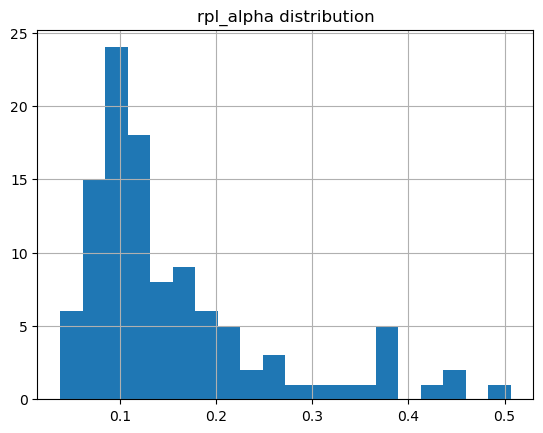

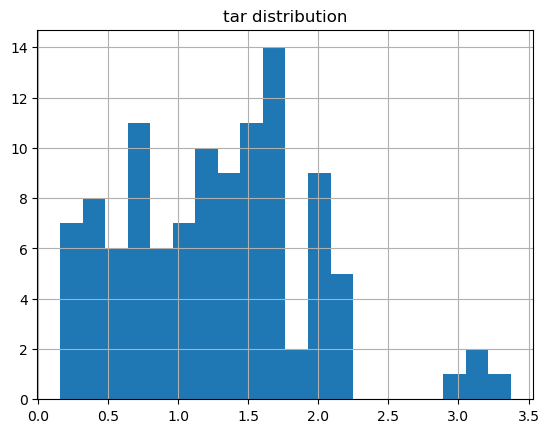

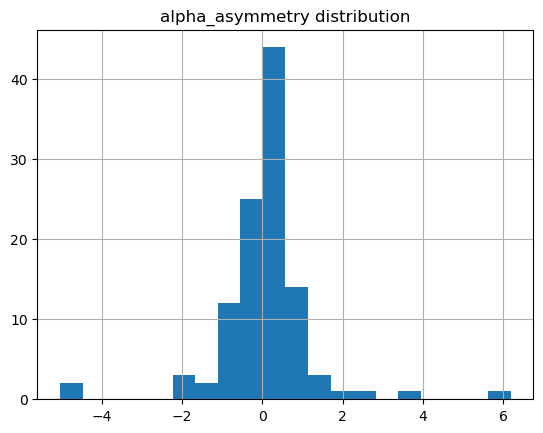

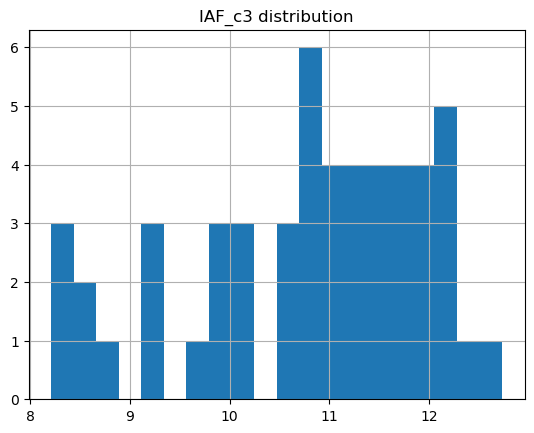

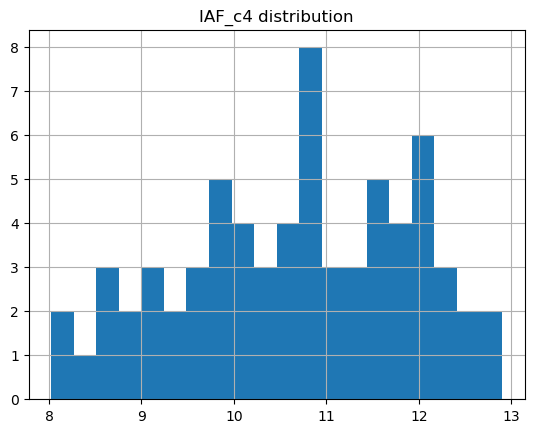

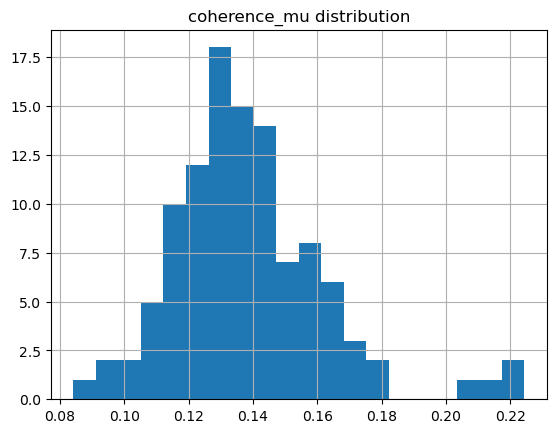

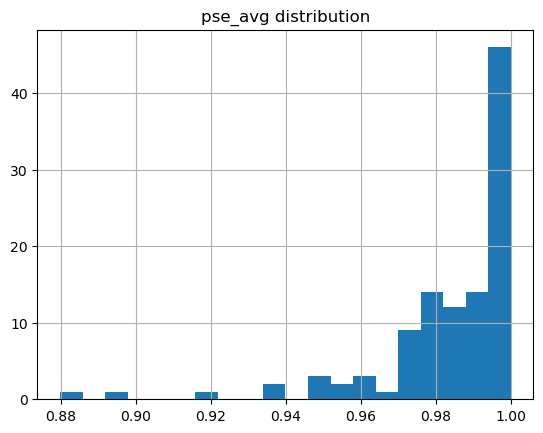

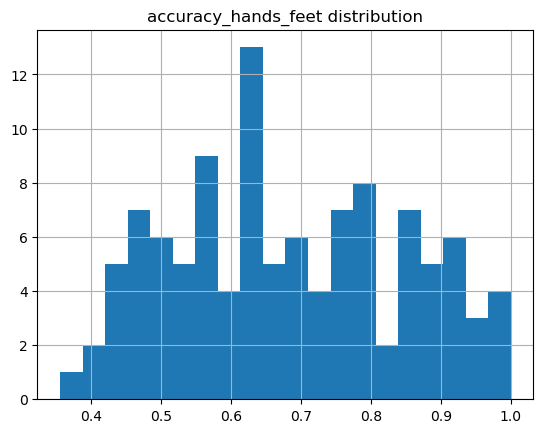

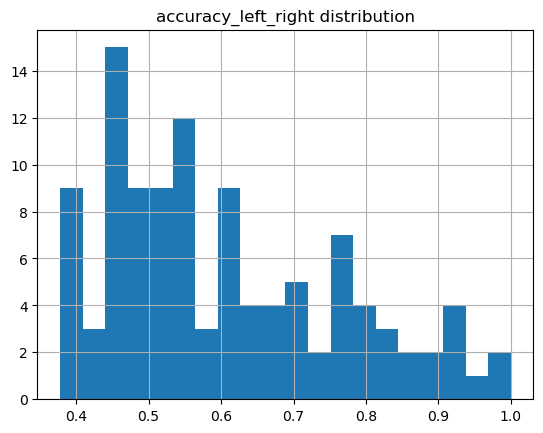

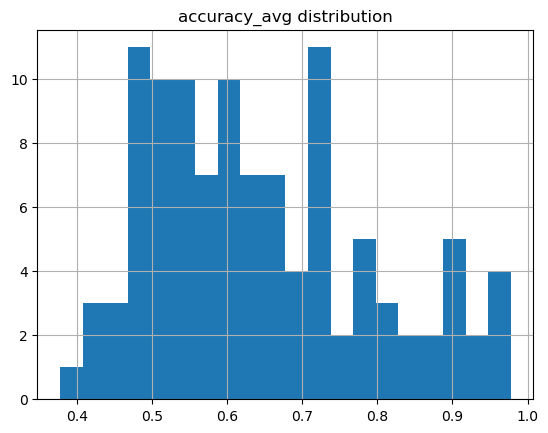

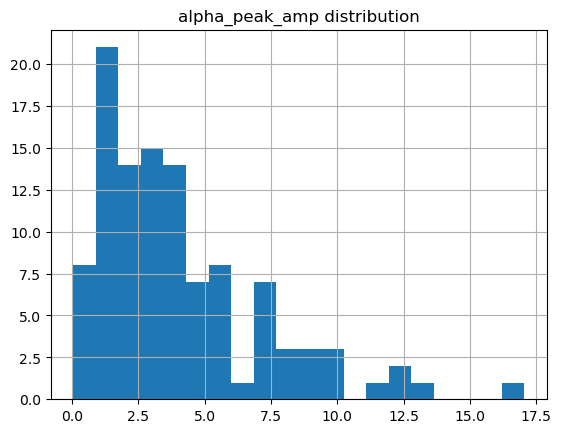

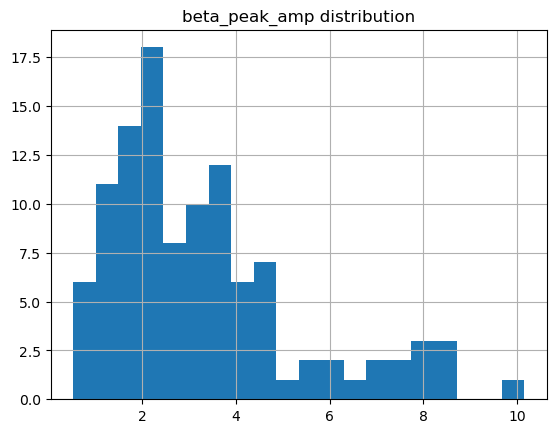

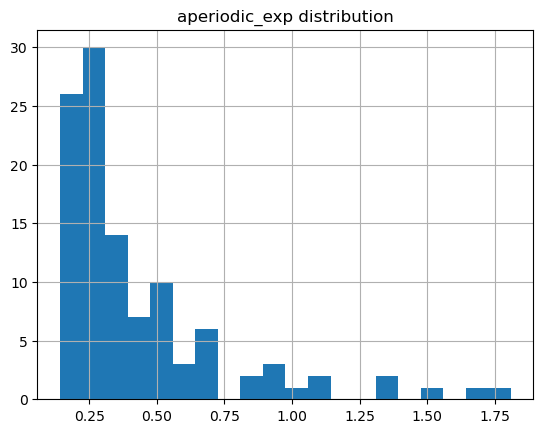

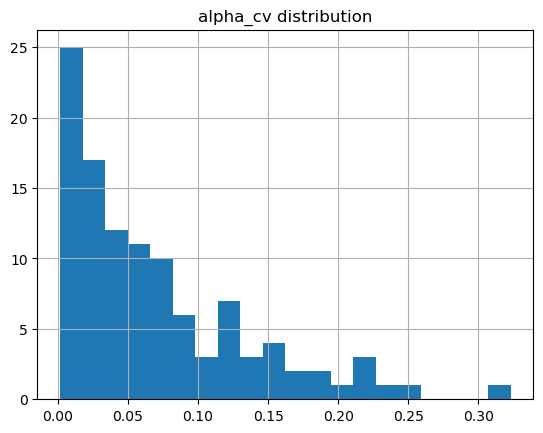

In [36]:
for col in df.columns[1:]:
    plt.figure()
    df[col].hist(bins = 20)
    plt.title(f"{col} distribution")
    plt.show()

# Next step: look at relationships between features and labels

In [37]:
df.columns

Index(['subject_id', 'rpl_alpha', 'tar', 'alpha_asymmetry', 'IAF_c3', 'IAF_c4',
       'coherence_mu', 'pse_avg', 'accuracy_hands_feet', 'accuracy_left_right',
       'accuracy_avg', 'alpha_peak_amp', 'beta_peak_amp', 'aperiodic_exp',
       'alpha_cv'],
      dtype='object')

In [38]:
# note: does not include subject ID or labels
numerical_cols = ['rpl_alpha', 'tar', 'alpha_asymmetry', 'IAF_c3', 'IAF_c4',
                  'coherence_mu', 'pse_avg', 'alpha_peak_amp', 'beta_peak_amp', 
                  'aperiodic_exp', 'alpha_cv']
numerical_cols

['rpl_alpha',
 'tar',
 'alpha_asymmetry',
 'IAF_c3',
 'IAF_c4',
 'coherence_mu',
 'pse_avg',
 'alpha_peak_amp',
 'beta_peak_amp',
 'aperiodic_exp',
 'alpha_cv']

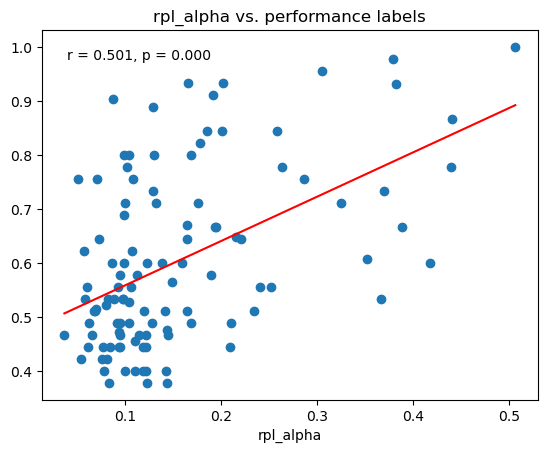

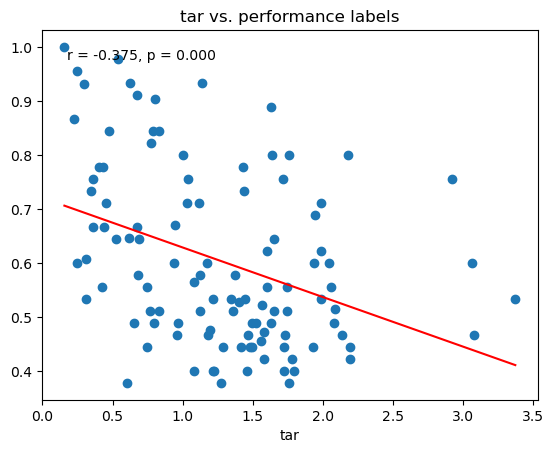

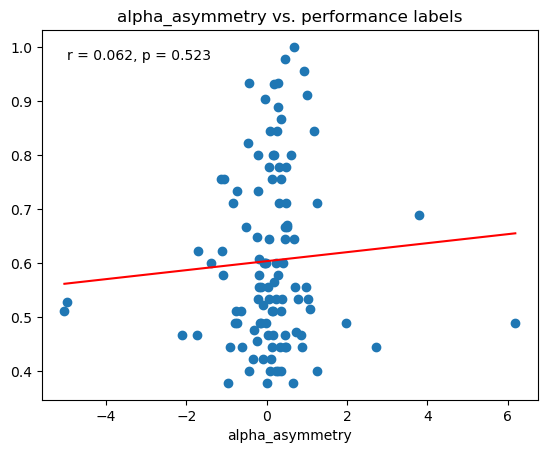

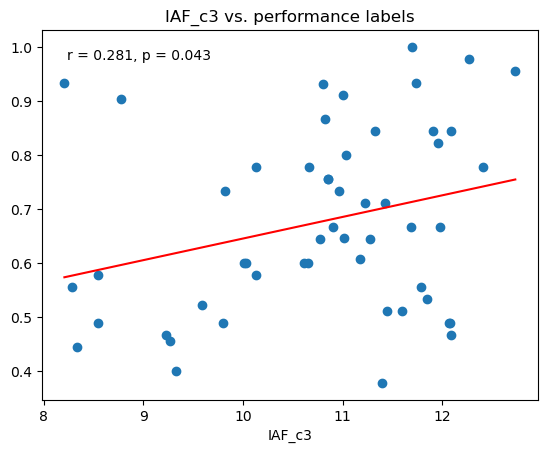

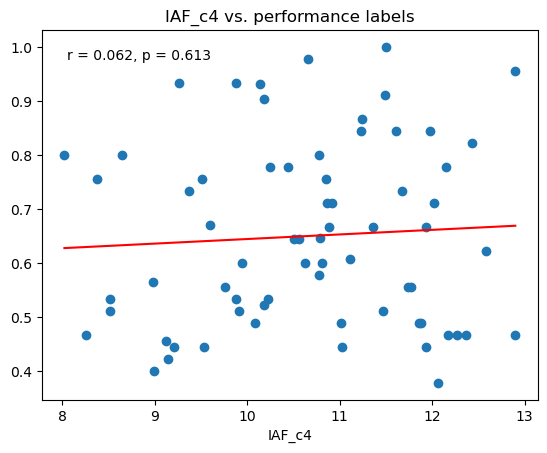

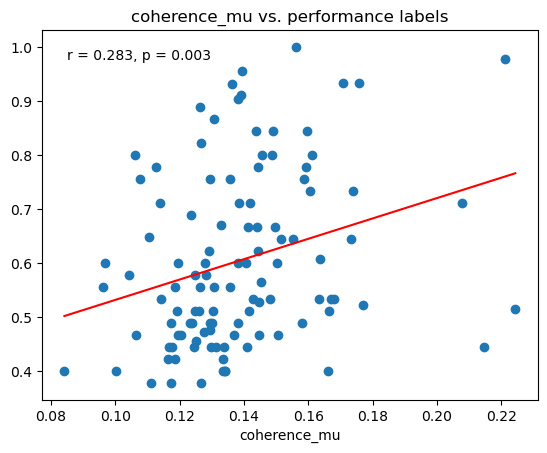

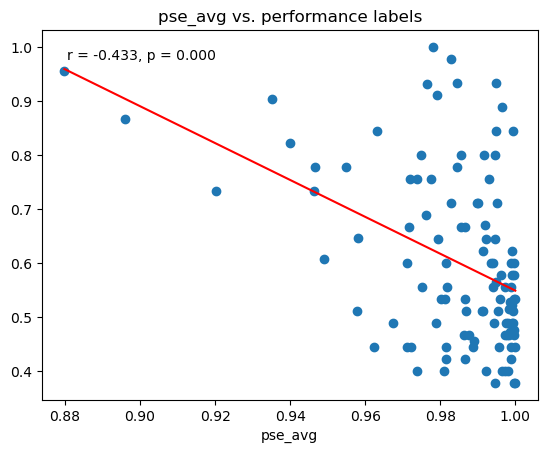

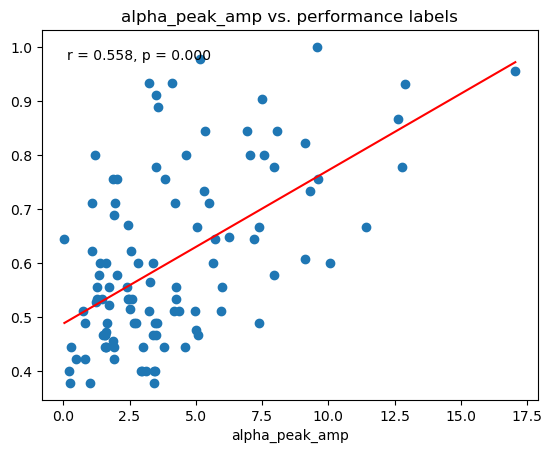

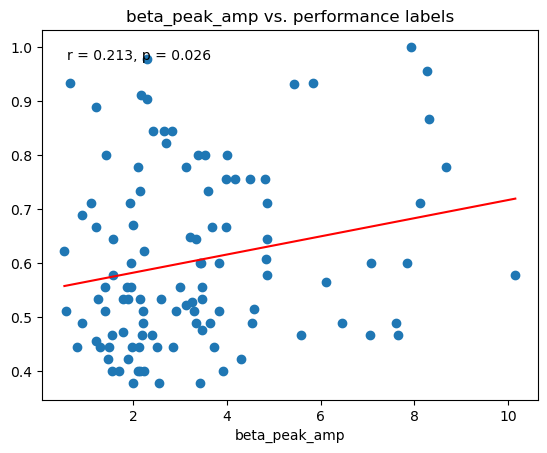

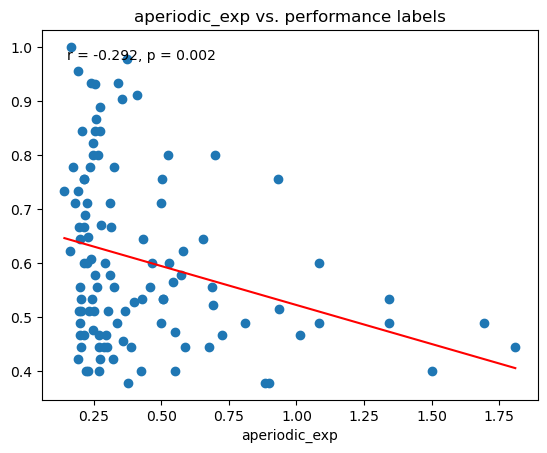

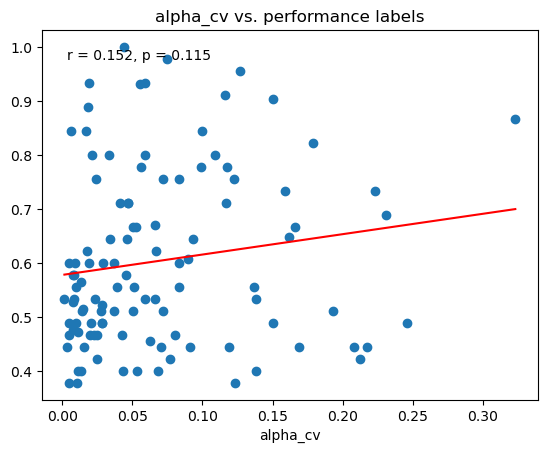

In [39]:
# correlation r values used: r < 0.3 is weak, r between .3 and .5 is moderate, r >= 0.5 is strong
for i in numerical_cols:
    plt.figure()
    mask = df[i].notna()
    x = df[i][mask].values
    y = df['accuracy_left_right'][mask].values
    
    r, p = stats.pearsonr(x, y)
    
    plt.scatter(x, y)
    m, b = np.polyfit(x, y, 1)
    plt.plot(np.sort(x), m * np.sort(x) + b, color='red')
    
    plt.title(f'{i} vs. performance labels')
    plt.xlabel(i)
    plt.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top')
    plt.show()

In [40]:
# Major findings
    # alpha asymmetry is vertical and doesn't seem predictive, will drop. Also had lowest correlation
        # of remaining cols when dropping earlier
    # !!! ceiling for pse, need to transform and investigate
    # beta peak amp and alpha cv are both essentially point clouds, will drop
    # aperiodic exp has a vertical col of points that seem to be convergence fails, 
        # changing extraction code did not fix, will also drop
    # IAF c3 and c4 both have weak correlations, look like point clouds too, + NMAR context -> drop


In [41]:
df = df.drop(columns = ['alpha_asymmetry', 'beta_peak_amp', 'alpha_cv', 'aperiodic_exp', 'IAF_c3', 'IAF_c4'])

In [42]:
df.head(5)

,subject_id,rpl_alpha,tar,coherence_mu,pse_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp
0,S001,0.194741,0.675380,0.141254,0.986568,0.888889,0.666667,0.777778,7.385356
1,S002,0.202166,0.624098,0.175790,0.994793,0.800000,0.933333,0.866667,4.109288
2,S003,0.099183,1.945952,0.123528,0.976120,0.533333,0.688889,0.611111,1.905932
3,S004,0.094906,1.370996,0.124825,0.999133,0.666667,0.577778,0.622222,1.352942
4,S005,0.058463,3.374198,0.167935,0.995939,0.466667,0.533333,0.500000,1.476744


# Next step: feature transformations according to distributions and scatter plots

In [43]:
df_final = df.copy()
df_final

,subject_id,rpl_alpha,tar,coherence_mu,pse_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp
0,S001,0.194741,0.675380,0.141254,0.986568,0.888889,0.666667,0.777778,7.385356
1,S002,0.202166,0.624098,0.175790,0.994793,0.800000,0.933333,0.866667,4.109288
2,S003,0.099183,1.945952,0.123528,0.976120,0.533333,0.688889,0.611111,1.905932
3,S004,0.094906,1.370996,0.124825,0.999133,0.666667,0.577778,0.622222,1.352942
4,S005,0.058463,3.374198,0.167935,0.995939,0.466667,0.533333,0.500000,1.476744
...,...,...,...,...,...,...,...,...,...
104,S105,0.159167,3.062739,0.138011,0.993949,0.755556,0.600000,0.677778,5.631262
105,S106,0.241216,0.749499,0.135554,0.981878,0.888889,0.555556,0.722222,4.250169
106,S107,0.141917,0.830067,0.141573,0.990991,0.666667,0.511111,0.588889,4.361831
107,S108,0.286493,0.361285,0.158633,0.973709,0.688889,0.755556,0.722222,9.605802


In [44]:
# log transforming skewed features
old_to_drop = ['rpl_alpha', 'pse_avg', 'alpha_peak_amp']

df_final['rpl_alpha_log'] = np.log10(df['rpl_alpha'])
df_final['pse_avg_log'] = np.log1p(1 - df['pse_avg'])  # left skewed, reflect first
df_final['alpha_peak_amp_log'] = np.log10(df['alpha_peak_amp'])

df_final = df_final.drop(columns = old_to_drop)

df_final.columns

Index(['subject_id', 'tar', 'coherence_mu', 'accuracy_hands_feet',
       'accuracy_left_right', 'accuracy_avg', 'rpl_alpha_log', 'pse_avg_log',
       'alpha_peak_amp_log'],
      dtype='object')

In [45]:
df_final.columns

Index(['subject_id', 'tar', 'coherence_mu', 'accuracy_hands_feet',
       'accuracy_left_right', 'accuracy_avg', 'rpl_alpha_log', 'pse_avg_log',
       'alpha_peak_amp_log'],
      dtype='object')

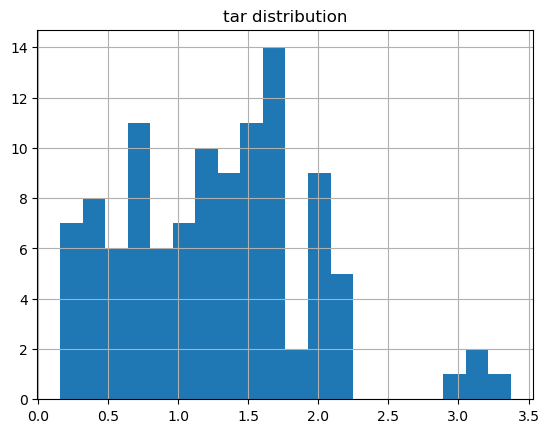

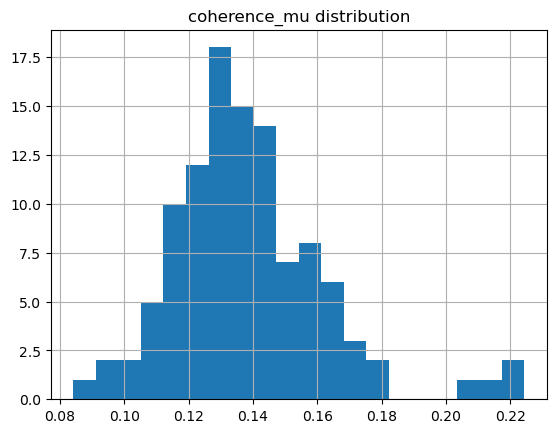

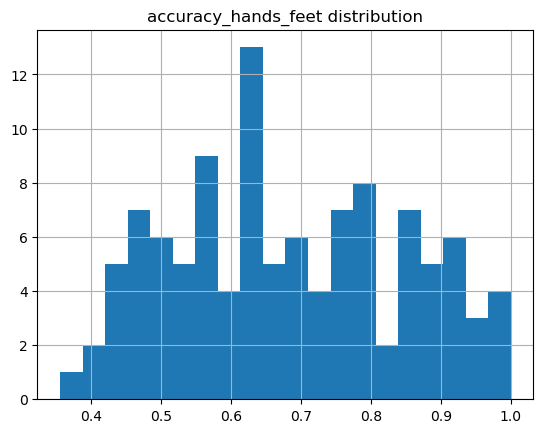

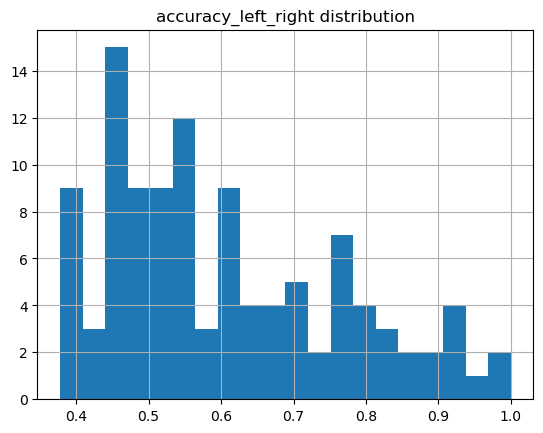

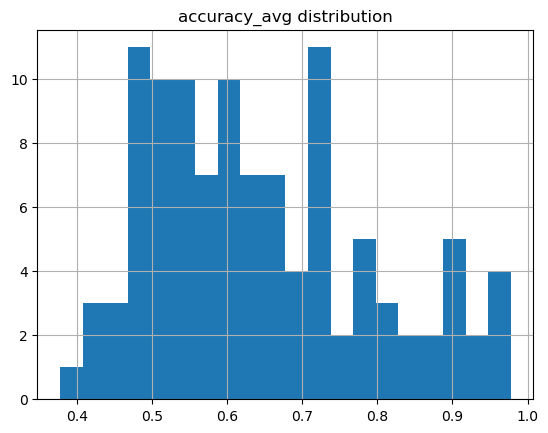

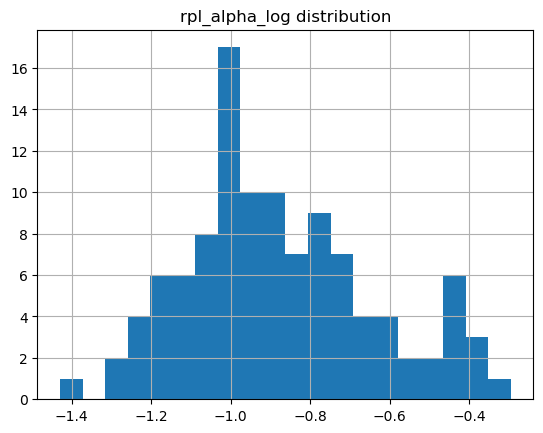

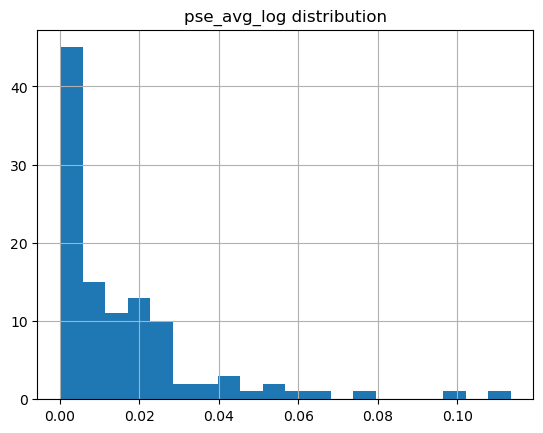

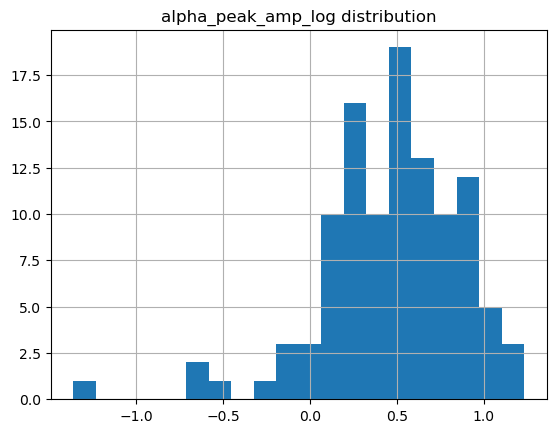

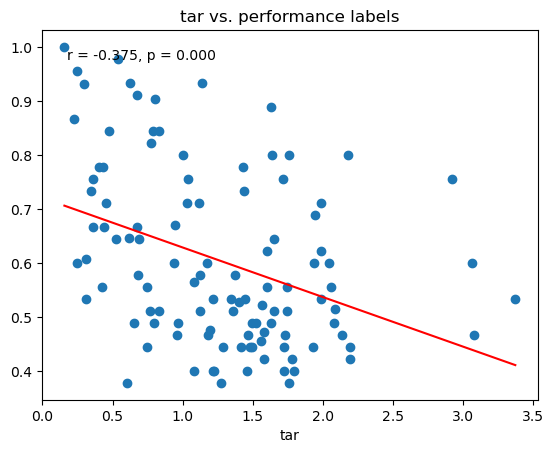

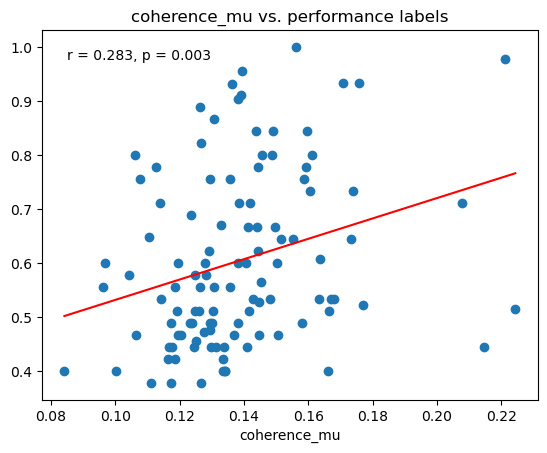

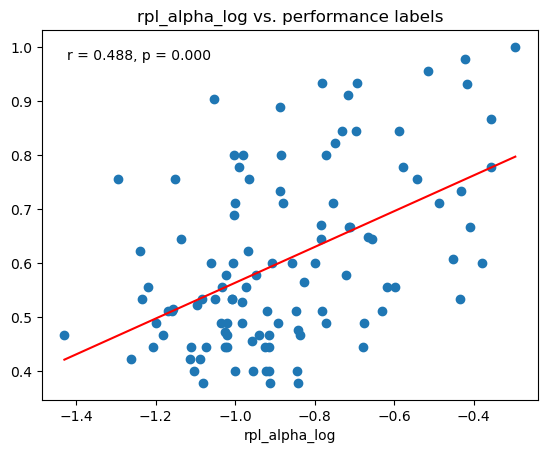

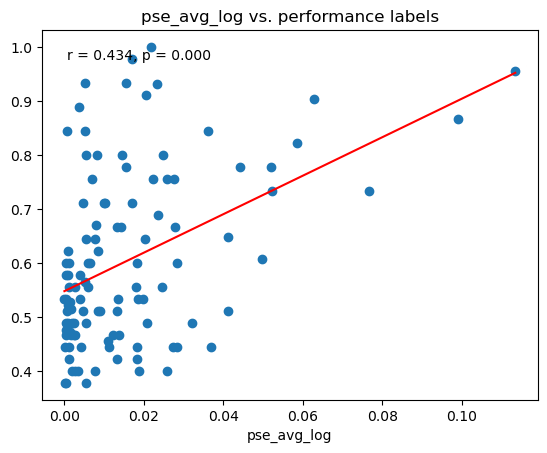

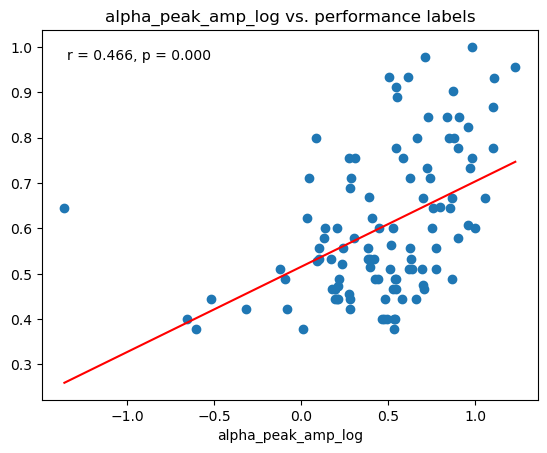

In [46]:
# correlation/ distribution investigations
for col in df_final.columns[1:]:
    plt.figure()
    df_final[col].hist(bins = 20)
    plt.title(f"{col} distribution")
    plt.show()

# correlation r values used: r < 0.3 is weak, r between .3 and .5 is moderate, r >= 0.5 is strong
corr_cols_final = ['tar', 'coherence_mu', 'rpl_alpha_log', 'pse_avg_log', 'alpha_peak_amp_log']

for i in corr_cols_final:
    plt.figure()
    mask = df_final[i].notna()
    x = df_final[i][mask].values
    y = df_final['accuracy_left_right'][mask].values
    
    r, p = stats.pearsonr(x, y)
    
    plt.scatter(x, y)
    m, b = np.polyfit(x, y, 1)
    plt.plot(np.sort(x), m * np.sort(x) + b, color='red')
    
    plt.title(f'{i} vs. performance labels')
    plt.xlabel(i)
    plt.text(0.05, 0.95, f'r = {r:.3f}, p = {p:.3f}', 
             transform=plt.gca().transAxes, verticalalignment='top')
    plt.show()

## transformation results

Unfortunately, correlations either dropped or stayed the same after transformation. Will not continue with transformations

this necessitates keeping some non-normal features, so I will continue with ensemble methods


# Identifying worst-performing users

In [47]:
df.head(5)
# 5 features remain:
    # rpl_alpha
    # tar
    # mu coherence
    # pse
    # alpha peak amp

,subject_id,rpl_alpha,tar,coherence_mu,pse_avg,accuracy_hands_feet,accuracy_left_right,accuracy_avg,alpha_peak_amp
0,S001,0.194741,0.675380,0.141254,0.986568,0.888889,0.666667,0.777778,7.385356
1,S002,0.202166,0.624098,0.175790,0.994793,0.800000,0.933333,0.866667,4.109288
2,S003,0.099183,1.945952,0.123528,0.976120,0.533333,0.688889,0.611111,1.905932
3,S004,0.094906,1.370996,0.124825,0.999133,0.666667,0.577778,0.622222,1.352942
4,S005,0.058463,3.374198,0.167935,0.995939,0.466667,0.533333,0.500000,1.476744


In [48]:
# worst users
df.sort_values(by = 'accuracy_left_right', ascending = True).head(10).drop(columns = ['accuracy_avg', 'accuracy_hands_feet'])

,subject_id,rpl_alpha,tar,coherence_mu,pse_avg,accuracy_left_right,alpha_peak_amp
57,S058,0.083225,1.759564,0.117342,0.999537,0.377778,0.246580
17,S018,0.122729,1.276771,0.126492,0.999829,0.377778,1.020932
58,S059,0.143782,0.603018,0.111004,0.994563,0.377778,3.410258
45,S046,0.121773,1.722678,0.133535,0.996534,0.400000,2.928083
46,S047,0.119563,1.077933,0.084127,0.998172,0.400000,3.465397
38,S039,0.099813,1.795249,0.100045,0.973902,0.400000,2.984595
27,S028,0.110787,1.458150,0.134095,0.980928,0.400000,3.103753
8,S009,0.078736,1.215918,0.166106,0.992289,0.400000,0.219085
77,S078,0.143470,1.221434,0.133986,0.997262,0.400000,3.412680
67,S068,0.081382,1.782382,0.116460,0.981505,0.422222,0.832322


In [49]:
# best users
df.sort_values(by = 'accuracy_left_right', ascending = False).head(10).drop(columns = ['accuracy_avg', 'accuracy_hands_feet'])

,subject_id,rpl_alpha,tar,coherence_mu,pse_avg,accuracy_left_right,alpha_peak_amp
28,S029,0.506655,0.156563,0.156281,0.978057,1.000000,9.562726
6,S007,0.379058,0.535938,0.221193,0.982866,0.977778,5.169266
41,S042,0.305061,0.248273,0.139333,0.879829,0.955556,17.050630
1,S002,0.202166,0.624098,0.175790,0.994793,0.933333,4.109288
55,S056,0.165434,1.140107,0.170773,0.984327,0.933333,3.216881
71,S072,0.382897,0.296236,0.136175,0.976482,0.930556,12.881350
93,S094,0.192367,0.676677,0.138996,0.979176,0.911111,3.490520
33,S034,0.088281,0.805341,0.137980,0.935231,0.902778,7.494320
69,S070,0.129932,1.633816,0.126443,0.996425,0.888889,3.569910
59,S060,0.440425,0.223261,0.130726,0.896003,0.866667,12.643060


In [50]:
# Immediate differences noticed

# higher performers tend to have
    # generally higher rpl_alpha
    # generally lower tar (< 1.0)
    # coherence mu pretty similar
    # generally lower pse_avg
    # generally higher alpha peaks

# Feature significance between high/low performers
- define significance level at 0.05

In [51]:
# significance testing: Spearman's correlation (as feature increases, does accuracy meaninfully increase?)
features = ['rpl_alpha', 'tar', 'coherence_mu', 'pse_avg', 'alpha_peak_amp']

pvals = []
rvals = []
for feature in features:
    r, p = spearmanr(df[feature], df['accuracy_left_right'])
    pvals.append(p)
    rvals.append(r)

rejected, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')  # fdr multiple testing

for feat, r, p_raw, p_corr, sig in zip(features, rvals, pvals, pvals_corrected, rejected):
    print(f"{feat}: r={r:.3f}, p_raw={p_raw:.3f}, p_corrected={p_corr:.3f}, significant={sig}\n")

rpl_alpha: r=0.456, p_raw=0.000, p_corrected=0.000, significant=True

tar: r=-0.388, p_raw=0.000, p_corrected=0.000, significant=True

coherence_mu: r=0.331, p_raw=0.000, p_corrected=0.000, significant=True

pse_avg: r=-0.381, p_raw=0.000, p_corrected=0.000, significant=True

alpha_peak_amp: r=0.503, p_raw=0.000, p_corrected=0.000, significant=True



In [52]:
# significance testing: permuation test (invetigating differences between high and low performers)
median_acc = df['accuracy_left_right'].median()
high = df[df['accuracy_left_right'] >= median_acc]
low = df[df['accuracy_left_right'] < median_acc]

pvals_perm = []
stats_perm = []

def statistic(x, y):
        return np.mean(x) - np.mean(y)

for feat in features:
    result = permutation_test(
        (high[feat].values, low[feat].values),
        statistic,
        permutation_type='independent',
        n_resamples=10000
    )
    pvals_perm.append(result.pvalue)
    stats_perm.append(result.statistic)

rejected_perm, pvals_perm_corrected, _, _ = multipletests(pvals_perm, method='fdr_bh')

for feat, stat, p_raw, p_corr, sig in zip(features, stats_perm, pvals_perm, pvals_perm_corrected, rejected_perm):
    print(f"{feat}: diff={stat:.3f}, p_raw={p_raw:.3f}, p_corrected={p_corr:.3f}, significant={sig}\n")

rpl_alpha: diff=0.081, p_raw=0.000, p_corrected=0.000, significant=True

tar: diff=-0.418, p_raw=0.001, p_corrected=0.001, significant=True

coherence_mu: diff=0.005, p_raw=0.280, p_corrected=0.280, significant=False

pse_avg: diff=-0.013, p_raw=0.001, p_corrected=0.001, significant=True

alpha_peak_amp: diff=2.790, p_raw=0.000, p_corrected=0.000, significant=True



# Significance testing results: SIGNIFICANCE
- all features significant for spearman
- all features significant for permutation

In [53]:
# creating design matrix and label series
X = df[features]
y = df['accuracy_left_right']

In [54]:
# random forest classifier (binary)

loocv = LeaveOneOut()
threshold = 0.65  # 70% accuracy is acceptable level for reliable MI-BCI performance, training can improve up to around 10%
y_class = (y >= threshold).astype(int)
y_pred_class = np.zeros(len(y_class))
print(f"High: {y_class.sum()}, Low: {(1-y_class).sum()}")

for train_idx, test_idx in loocv.split(X):  # split into 108 trains, 1 test

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train = y_class.iloc[train_idx]

    model_rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 4,
        max_features = 5,
        class_weight = {0: 2, 1: 1} # penalize missing low performers (class 0) more than high performers
    )

    model_rf.fit(X_train, y_train)
    y_pred_class[test_idx] = model_rf.predict(X_test)

print(f"LOOCV Accuracy: {accuracy_score(y_class, y_pred_class):.4f}")
print(f"Baseline: {max(y_class.mean(), 1-y_class.mean()):.4f}")

High: 36, Low: 73
LOOCV Accuracy: 0.7523
Baseline: 0.6697


In [55]:
# other metrics
print(confusion_matrix(y_class, y_pred_class))
print(classification_report(y_class, y_pred_class, target_names=['Low', 'High']))

[[66  7]
 [20 16]]
              precision    recall  f1-score   support

         Low       0.77      0.90      0.83        73
        High       0.70      0.44      0.54        36

    accuracy                           0.75       109
   macro avg       0.73      0.67      0.69       109
weighted avg       0.74      0.75      0.74       109



In [56]:
model_rf = RandomForestClassifier(
        n_estimators = 200,
        max_depth = 4,
        max_features = 5,
        class_weight = {0: 2, 1: 1}
    )
model_rf.fit(X, y_class)

importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances)

alpha_peak_amp    0.315871
pse_avg           0.221706
rpl_alpha         0.196344
coherence_mu      0.144992
tar               0.121087
dtype: float64


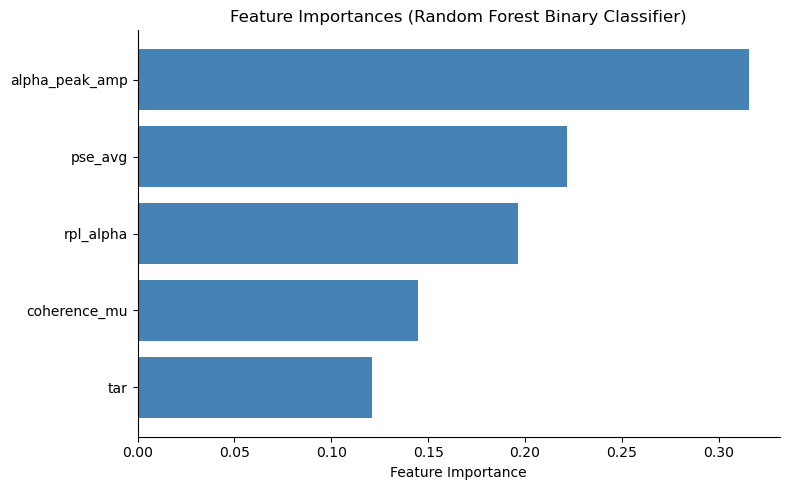

In [57]:
# feature importances

significance = importances.head(5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(significance.index[::-1], significance.values[::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importances (Random Forest Binary Classifier)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

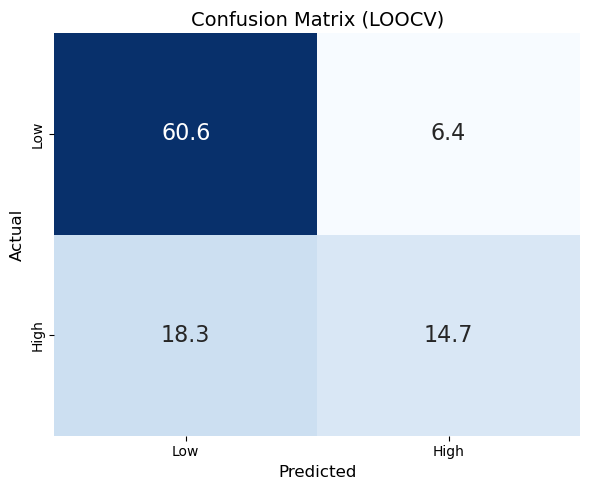

In [58]:
# confusion matrix
cm = confusion_matrix(y_class, y_pred_class)
cm_pct = cm.astype(float) / cm.sum() * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='Blues',
    xticklabels=['Low', 'High'],
    yticklabels=['Low', 'High'],
    ax=ax,
    cbar=False,
    annot_kws={'size': 16}
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (LOOCV)', fontsize=14)
plt.tight_layout()
plt.show()